In [1]:
# ------------------------------------------------------------------------------------------
# Cell 0: Environment / Imports / Paths / Plot Settings
# Run this cell first whenever you restart the kernel
# ------------------------------------------------------------------------------------------

# ------------------------------
# Imports
# ------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial import KDTree

# ------------------------------
# PyVista backend for Jupyter
# ------------------------------
pv.set_jupyter_backend('trame')

# ------------------------------
# Input directory
# ------------------------------
input_vtk_dir = "./S1-CM50-COMBINED-vtk///"
input_vtk_basename = os.path.basename(os.path.normpath(input_vtk_dir))

# ------------------------------
# Output directories
# ------------------------------
output_base_dir = os.path.join("./Inter-ODP-Output/", input_vtk_basename)
plots_dir = os.path.join(output_base_dir, "plots")
screenshots_dir = os.path.join(output_base_dir, "screenshots")
dsm_html_dir = os.path.join(output_base_dir, "dsm_html")
output_dirs = [plots_dir, screenshots_dir, dsm_html_dir]

for output_dir in output_dirs:
    os.makedirs(output_dir, exist_ok=True)


# Matplotlib settings for Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Arial'

# ------------------------------
# Scatter / jitter settings
# ------------------------------
jitter_width = 0.08

# ------------------------------
# Summary printout
# ------------------------------
print(f"Input VTK directory: {input_vtk_dir}")
print(f"Output base directory: {output_base_dir}")
print(f"Plots directory: {plots_dir}")
print(f"Screenshots directory: {screenshots_dir}")
print(f"DSM HTML directory: {dsm_html_dir}")
print("Reproducible random seed set: 0")


Input VTK directory: ./S1-CM50-COMBINED-vtk///
Output base directory: ./Inter-ODP-Output/S1-CM50-COMBINED-vtk
Plots directory: ./Inter-ODP-Output/S1-CM50-COMBINED-vtk\plots
Screenshots directory: ./Inter-ODP-Output/S1-CM50-COMBINED-vtk\screenshots
DSM HTML directory: ./Inter-ODP-Output/S1-CM50-COMBINED-vtk\dsm_html
Reproducible random seed set: 0


In [2]:
#Cell 1: Generates PtP distance plots, screenshots, and htmls of vtk files

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# Grid appearance
grid_color = "lightgrey"
grid_linestyle = ":"

title_fontsize = 16
axis_fontsize = 14
tick_fontsize = 12
legend_fontsize = 12

# Plot appearance
plot_width = 10
plot_height = 6
plot_background = "ghostwhite"
x_axis_limits = None
y_axis_limits = None
point_size = 12

# ------------------------------
# Functions
# ------------------------------
def histPlotOfDistances(d_kdtree, fname, save_dir, want_png=True, want_pdf=True, want_pdf_transparent=True):
    sorted_d_kdtree = np.sort(d_kdtree)
    n_hist, bins, patches = plt.hist(d_kdtree, bins=20, histtype="step", color="black", label="Distances")
    hist_max = np.max(n_hist)
    
    lower_quartile = np.quantile(sorted_d_kdtree, 0.25)
    mean_of_lower_half = np.mean(sorted_d_kdtree[:len(sorted_d_kdtree)//2])

    # Vertical lines
    plt.vlines(lower_quartile, 0, hist_max, color="red", label="Lower quartile")
    plt.vlines(mean_of_lower_half, 0, hist_max, color="purple", label="Mean of lower half")

    # Labels and title
    plt.xlabel("Distance to other ODP [nm]", fontsize=axis_fontsize)
    plt.ylabel("Count", fontsize=axis_fontsize)
    plt.title(fname, fontsize=title_fontsize)

    # Grid below data
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, linestyle=grid_linestyle, color=grid_color, alpha=0.7)

    # Show legend
    plt.legend(fontsize=legend_fontsize)

    # Save files
    if want_png:
        plt.savefig(os.path.join(save_dir, fname[:-4] + "_hist.png"), dpi=300, bbox_inches="tight")
    if want_pdf:
        plt.savefig(os.path.join(save_dir, fname[:-4] + "_hist.pdf"), dpi=300, bbox_inches="tight")
    if want_pdf_transparent:
        plt.savefig(os.path.join(save_dir, fname[:-4] + "_hist_transparent.pdf"),
                    dpi=300, bbox_inches="tight", transparent=True)
    
    plt.clf()


def screenshotDesmosomeMeshes(surf, other_half, fname, screenshots_dir, html_dir, want_png=True, want_html=False):
    p = pv.Plotter(off_screen=True)
    p.add_mesh(other_half, color=True, opacity=0.5, smooth_shading=True)
    p.add_mesh(surf, scalars="Nearest Distance [nm]", smooth_shading=True)
    if want_png:
        p.show(screenshot=os.path.join(screenshots_dir, fname[:-4] + ".png"))
    if want_html:
        p.export_html(os.path.join(html_dir, fname[:-4] + ".html"))

# ------------------------------
# Load input files
# ------------------------------
input_vtks = sorted(os.listdir(input_vtk_dir))
df_columns = ["ID", "lower quartile distance [nm]"]
df = pd.DataFrame(columns=df_columns)

# ------------------------------
# Process each desmosome
# ------------------------------
for f in input_vtks:
    f_path = os.path.join(input_vtk_dir, f)
    print(f)
    mesh = pv.read(f_path)
    #mesh.spacing = (4, 4, 4)  # convert to nm
    
    # Split the mesh into two
    bodies = mesh.split_bodies()
    
    # Extract the surface from one half
    surf = bodies[0].extract_surface()

    # KD-tree on the other half
    tree = KDTree(bodies[1].points)
    d_kdtree, idx = tree.query(surf.points)
    d_kdtree *= 1e9  # to nm
    surf["Nearest Distance [nm]"] = d_kdtree
    
    # Compute lower quartile
    lower_quartile = np.quantile(np.sort(d_kdtree), 0.25)
    df = pd.concat([df, pd.DataFrame([[f[:-4], lower_quartile]], columns=df_columns)])
    
    # Screenshots and histograms
    screenshotDesmosomeMeshes(surf, bodies[1], f, screenshots_dir, dsm_html_dir, True, True)
    histPlotOfDistances(d_kdtree, f, plots_dir, True, False, False)

df.to_pickle(os.path.join(output_base_dir, "lower_quartiles.pkl")) 
# pickling serializes the dataframe (df) object so that pd.read_pickle in the next cell 
# can do the graphs even if the kernel is closed

A_left-CM50-DSM1.vtk


Widget(value='<iframe src="http://localhost:62639/index.html?ui=P_0x1ee053cfb50_0&reconnect=auto" class="pyvis…

A_left-CM50-DSM2.vtk


Widget(value='<iframe src="http://localhost:62639/index.html?ui=P_0x1ee0e8b0a60_1&reconnect=auto" class="pyvis…

A_left-CM50-DSM3.vtk


...

Widget(value='<iframe src="http://localhost:62639/index.html?ui=P_0x1ee53dfe410_21&reconnect=auto" class="pyvi…

MA-CM50-DSM4.vtk


Widget(value='<iframe src="http://localhost:62639/index.html?ui=P_0x1ee0e97df60_22&reconnect=auto" class="pyvi…

<Figure size 640x480 with 0 Axes>

 JS Error => Error compiling shader '#version 300 es
#define attribute in
#define textureCube texture
#define texture2D texture
#define textureCubeLod textureLod
#define texture2DLod textureLod


#ifdef GL_FRAGMENT_PRECISION_HIGH
precision highp float;
precision highp int;
#else
precision mediump float;
precision mediump int;
#endif

/*=========================================================================

  Program:   Visualization Toolkit
  Module:    vtkPolyDataVS.glsl

  Copyright (c) Ken Martin, Will Schroeder, Bill Lorensen
  All rights reserved.
  See Copyright.txt or http://www.kitware.com/Copyright.htm for details.

     This software is distributed WITHOUT ANY WARRANTY; without even
     the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR
     PURPOSE.  See the above copyright notice for more information.

=========================================================================*/

attribute vec4 vertexMC;

// frag position in VC
out vec4 vertexVCVSOutput;


First few rows of lower quartile values:
                  ID  lower quartile distance [nm]
0   A_left-CM50-DSM1                     44.368491
0   A_left-CM50-DSM2                     45.786298
0   A_left-CM50-DSM3                     42.769435
0   A_left-CM50-DSM4                     48.172936
0   A_left-CM50-DSM5                     44.281069
0   A_left-CM50-DSM6                     43.997432
0   A_left-CM50-DSM7                     35.443788
0   A_left-CM50-DSM8                     45.354225
0  A_right-CM50-DSM1                     55.489078
0  A_right-CM50-DSM2                     40.338037
Lower quartile values saved to: ./Inter-ODP-Output/S1-CM50-COMBINED-vtk\S1-CM50-COMBINED-vtk_lower_quartiles.xlsx


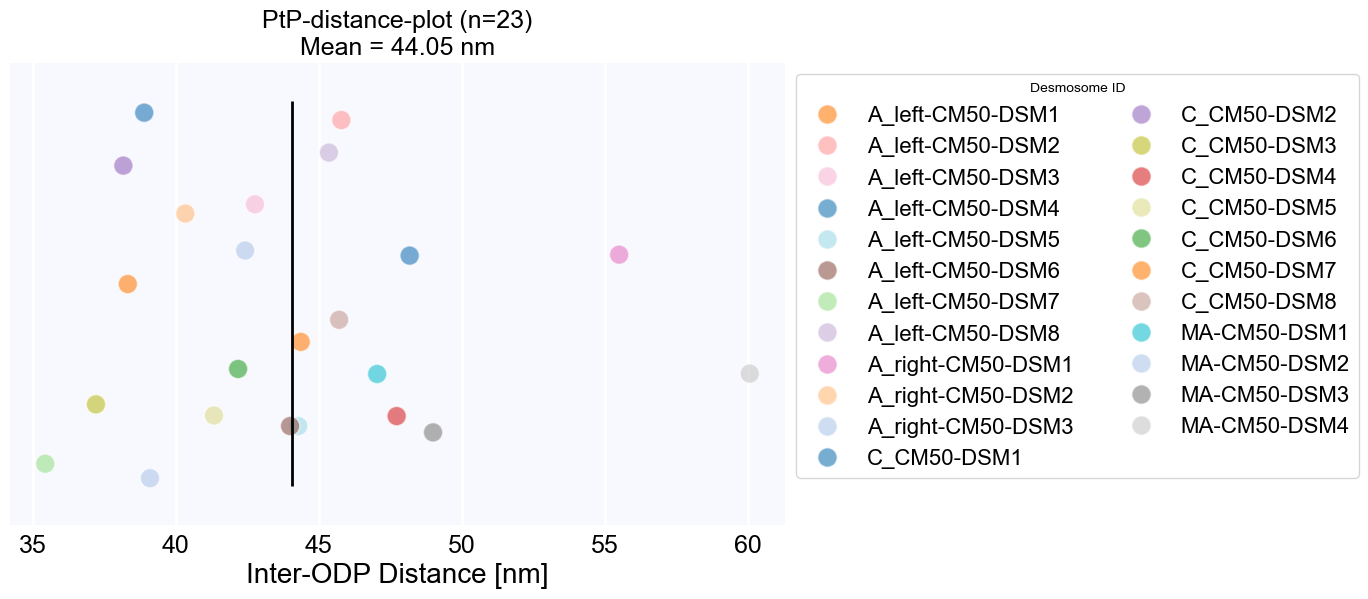

In [3]:
#Cell 2: Run pkl file to get excel output

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
from matplotlib.colors import to_rgba

pickle_path = os.path.join(output_base_dir, "lower_quartiles.pkl")

if not os.path.exists(pickle_path):
    raise FileNotFoundError(
        f"Pickle file not found:\n{pickle_path}\n"
        "Run Cell 1 once to generate it."
    )

df = pd.read_pickle(pickle_path) # loads the dataframe (df) wihtout having to process all vtks in cell 1 again

# ------------------------------
# Plot appearance
# ------------------------------
plot_width = 10
plot_height = 6
plot_background = "ghostwhite"
x_axis_limits = None
y_axis_limits = None
point_size = 14
mean_line_height = 1  # adjustable height of the mean line above points

title_fontsize1 = 18
axis_fontsize1 = 20
tick_fontsize1 = 18
legend_fontsize1 = 16

# Grid appearance
grid_color1 = "white"
grid_linestyle1 = "-"

# ------------------------------
# Set global font and sizes
# ------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.titlesize'] = title_fontsize1
plt.rcParams['axes.labelsize'] = axis_fontsize1
plt.rcParams['xtick.labelsize'] = tick_fontsize1
plt.rcParams['ytick.labelsize'] = tick_fontsize1
plt.rcParams['legend.fontsize'] = legend_fontsize1

# Random vertical offsets for points
np.random.seed(42)
df["y_random"] = np.random.uniform(low=0, high=1, size=len(df))

# ------------------------------
# Color-blind-friendly palette (tab20)
# ------------------------------
unique_ids = df["ID"].unique()
n_ids = len(unique_ids)
base_colors = plt.get_cmap("tab20").colors
if n_ids <= 20:
    colors = base_colors[:n_ids]
else:
    # repeat colors if more than 20
    colors = [base_colors[i % 20] for i in range(n_ids)]
np.random.shuffle(colors)
id_to_color = dict(zip(unique_ids, colors))

# ------------------------------
# Strip plot
# ------------------------------
plt.figure(figsize=(plot_width, plot_height))
ax = plt.gca()
ax.set_facecolor(plot_background)
ax.set_axisbelow(True)  # grid below points

strip_plot = sns.scatterplot(
    data=df,
    x="lower quartile distance [nm]",
    y="y_random",
    hue="ID",
    palette=id_to_color,
    alpha=0.6,
    s=point_size**2,
    legend="full"
)

# ------------------------------
# Vertical mean line with adjustable height
# ------------------------------
mean_lower_quartile = df["lower quartile distance [nm]"].mean()
mean_line_bottom = -0.10
mean_line_top = 1  # float above the points
plt.vlines(
    x=mean_lower_quartile,
    ymin=0,                    # bottom of line
    ymax=mean_line_top,     # top of line
    color="k",
    linestyle="-",
    linewidth=2,
    label=f"Mean = {mean_lower_quartile:.2f} nm"
)

# ------------------------------
# Hide y-axis numbers and ticks
# ------------------------------
ax.set_yticks([])
ax.set_yticklabels([])

# Labels and title
strip_plot.tick_params(left=False, bottom=False, labelsize=tick_fontsize1)
plt.xlabel("Inter-ODP Distance [nm]", fontsize=axis_fontsize1)
plt.ylabel("")
n_samples = len(df)
plt.title(
    f"PtP-distance-plot (n={n_samples})\nMean = {mean_lower_quartile:.2f} nm",
    fontsize=title_fontsize1
)

# Legend
if strip_plot.get_legend() is not None:
    sns.move_legend(strip_plot, "upper left", bbox_to_anchor=(1,1), ncol=2,
                    title="Desmosome ID", fontsize=legend_fontsize1)

# Axis limits
if x_axis_limits:
    plt.xlim(x_axis_limits)
if y_axis_limits:
    plt.ylim(y_axis_limits)
else:
    plt.ylim(-0.1, mean_line_height + 0.1)

# Grid and remove frame
ax.xaxis.grid(True, linestyle=grid_linestyle1, color=grid_color1, linewidth=2, alpha=1)
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------
# Preview first few rows
# ------------------------------
print("First few rows of lower quartile values:")
print(df[["ID", "lower quartile distance [nm]"]].head(10))

# ------------------------------
# Save lower quartile values to Excel
# ------------------------------
excel_output_path = os.path.join(output_base_dir, f"{input_vtk_basename}_lower_quartiles.xlsx")
df_to_save = df.drop(columns="y_random", errors='ignore')  # remove temporary column if exists
df_to_save.to_excel(excel_output_path, index=False)
print(f"Lower quartile values saved to: {excel_output_path}")

# ------------------------------
# Save figure
# ------------------------------
filename_base = f"{input_vtk_basename}_PtP-distance-plot"
plt.savefig(os.path.join(plots_dir, f"{filename_base}.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(plots_dir, f"{filename_base}.pdf"), dpi=300, bbox_inches="tight")
plt.show()
